<a href="https://colab.research.google.com/github/EvenSol/NeqSim-Colab/blob/master/notebooks/power/electrical_engineering_fundamentals_oil_gas.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Fundamentals of electrical engineering in oil and gas operations

This notebook connects **process duty to electrical-system behaviour**. A synthetic oil and
gas facility is solved with current NeqSim source code. Compressor and water-injection pump
shaft powers then become the largest loads in an 11 kV electrical distribution study built
with NumPy, pandas, SciPy, and Matplotlib.

The notebook is a teaching and screening example. It is **not** a certified load-flow,
short-circuit, protection, arc-flash, hazardous-area, cable, or equipment-selection study.

## Learning outcomes

After completing the notebook, you should be able to:

- distinguish real, reactive, apparent, and complex power in a balanced three-phase system;
- translate NeqSim compressor and pump duties into motor, VFD, feeder, and transformer loads;
- build and audit a facility load list with demand factors and operating cases;
- estimate voltage drop, losses, short-circuit current, motor-starting voltage dip, and
  protection coordination;
- explain harmonics, earthing, hazardous areas, UPS/emergency power, N+1 capacity, and load
  shedding in an oil and gas operating context; and
- identify when a screening calculation must be handed to a specialist power-system tool.

## Synthetic case and unit convention

The case represents a compact production facility with a gas export compressor and a
high-pressure water-injection pump. All facility, electrical, cable, transformer, and
operating data are editable **synthetic teaching assumptions**. Pressures are absolute
(`bara`), shaft and electrical power are in MW, line-to-line voltage is in kV RMS, and
frequency is 50 Hz.


## 0. How process and electrical engineering meet

The energy chain is:

**reservoir and process conditions → fluid duty → shaft power → motor/VFD input → cable and
transformer loading → generation or grid demand**.

NeqSim owns the thermodynamic state and process-equipment duty. The Python electrical model
owns balanced steady-state calculations and transparent screening equations. The boundary
matters: `Compressor.getPower("MW")` and `Pump.getPower("MW")` are treated as **shaft loads**;
motor and converter losses are added only once on the electrical side.

A complete project also needs verified vendor data, a single-line diagram, load-flow and
fault models, protection settings, cable installation details, earthing philosophy,
hazardous-area documentation, and operational procedures.


In [1]:
import hashlib
import importlib.util
import os
import platform
import shutil
import subprocess
import sys
from pathlib import Path

NEQSIM_REPOSITORY = "https://github.com/equinor/neqsim.git"
NEQSIM_SOURCE_REF = "0c1dfa371e20a6d0a274d6f756ea6d5ed8a0408a"
NEQSIM_EXPECTED_COMMIT = NEQSIM_SOURCE_REF
os.environ["NEQSIM_JVM_AUTOSTART"] = "0"

if importlib.util.find_spec("jpype") is None:
    subprocess.check_call(
        [
            sys.executable,
            "-m",
            "pip",
            "install",
            "--quiet",
            "neqsim==3.16.0",
        ]
    )

source_override = os.environ.get("NEQSIM_SOURCE_ROOT")
jar_override = os.environ.get("NEQSIM_SOURCE_JAR")
if source_override and jar_override:
    neqsim_root = Path(source_override)
    neqsim_jar = Path(jar_override)
else:
    neqsim_root = Path("/tmp") / f"neqsim-source-{NEQSIM_SOURCE_REF[:12]}"
    if not (neqsim_root / ".git").exists():
        shutil.rmtree(neqsim_root, ignore_errors=True)
        subprocess.check_call(
            [
                "git",
                "init",
                "--quiet",
                "--initial-branch",
                "colab-build",
                str(neqsim_root),
            ]
        )
        subprocess.check_call(
            [
                "git",
                "-C",
                str(neqsim_root),
                "remote",
                "add",
                "origin",
                NEQSIM_REPOSITORY,
            ]
        )
        subprocess.check_call(
            [
                "git",
                "-C",
                str(neqsim_root),
                "fetch",
                "--quiet",
                "--depth",
                "1",
                "origin",
                NEQSIM_SOURCE_REF,
            ]
        )
        subprocess.check_call(
            [
                "git",
                "-C",
                str(neqsim_root),
                "checkout",
                "--quiet",
                "--detach",
                "FETCH_HEAD",
            ]
        )

    jar_candidates = list((neqsim_root / "target").glob("neqsim-*.jar"))
    jar_candidates = [
        path
        for path in jar_candidates
        if not path.name.startswith("original-")
        and "-sources" not in path.name
        and "-javadoc" not in path.name
    ]
    if not jar_candidates:
        build_command = [
            str(neqsim_root / "mvnw"),
            "--quiet",
            "-Dmaven.test.skip=true",
            "-Dmaven.javadoc.skip=true",
            "package",
        ]
        completed = subprocess.run(
            build_command,
            cwd=neqsim_root,
            text=True,
            stdout=subprocess.PIPE,
            stderr=subprocess.STDOUT,
        )
        if completed.returncode != 0:
            print("\n".join(completed.stdout.splitlines()[-120:]))
            completed.check_returncode()
        jar_candidates = [
            path
            for path in (neqsim_root / "target").glob("neqsim-*.jar")
            if not path.name.startswith("original-")
            and "-sources" not in path.name
            and "-javadoc" not in path.name
        ]
    neqsim_jar = max(jar_candidates, key=lambda path: path.stat().st_size)

resolved_commit = subprocess.check_output(
    ["git", "-C", str(neqsim_root), "rev-parse", "HEAD"],
    text=True,
).strip()
assert resolved_commit == NEQSIM_EXPECTED_COMMIT
jar_sha256 = hashlib.sha256(neqsim_jar.read_bytes()).hexdigest()

import jpype

jpype.addClassPath(str(neqsim_jar))
if not jpype.isJVMStarted():
    jpype.startJVM()

JClass = jpype.JClass
MainOnlyClass = JClass(
    "neqsim.process.equipment.powergeneration.gasturbine.GasTurbineUnit"
)
class_location = str(
    MainOnlyClass.class_.getProtectionDomain().getCodeSource().getLocation()
)
assert neqsim_jar.name in class_location

java_system = JClass("java.lang.System")
print(f"NeqSim source commit: {resolved_commit}")
print(f"NeqSim source-built JAR: {neqsim_jar.name}")
print(f"JAR SHA-256: {jar_sha256}")
print(f"Main-only class source: {class_location}")
print(f"Python: {platform.python_version()}")
print(f"Java: {java_system.getProperty('java.version')}")


NeqSim source commit: 0c1dfa371e20a6d0a274d6f756ea6d5ed8a0408a
NeqSim source-built JAR: neqsim-3.18.0.jar
JAR SHA-256: 4f64571df09d4e21a1cbe990db4cb646d6828b3178b4a1c3d8c5d682290751a2
Main-only class source: file:/workspace/scratch/313e041c569b/neqsim-master/target/neqsim-3.18.0.jar
Python: 3.12.13
Java: 17.0.19


In [2]:
import math

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from scipy.optimize import brentq

SystemSrkEos = JClass("neqsim.thermo.system.SystemSrkEos")
SystemSrkCPA = JClass("neqsim.thermo.system.SystemSrkCPAstatoil")
Stream = JClass("neqsim.process.equipment.stream.Stream")
Compressor = JClass("neqsim.process.equipment.compressor.Compressor")
Pump = JClass("neqsim.process.equipment.pump.Pump")
ProcessSystem = JClass("neqsim.process.processmodel.ProcessSystem")

plt.style.use("seaborn-v0_8-whitegrid")
COLORS = {
    "process": "#0072B2",
    "electrical": "#D55E00",
    "safe": "#009E73",
    "warning": "#CC79A7",
    "neutral": "#5A5A5A",
}
pd.set_option("display.precision", 4)


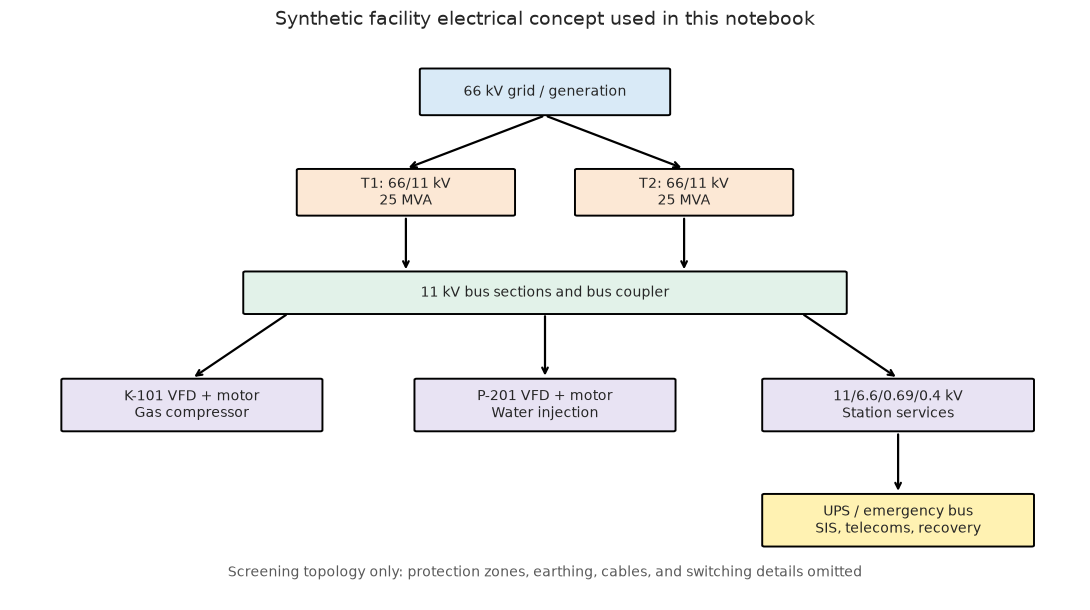

In [3]:
from matplotlib.patches import FancyBboxPatch

def add_system_box(axis, center_x, center_y, width, height, text, color):
    box = FancyBboxPatch(
        (center_x - width / 2.0, center_y - height / 2.0),
        width,
        height,
        boxstyle="round,pad=0.02",
        facecolor=color,
        edgecolor="black",
        linewidth=1.4,
    )
    axis.add_patch(box)
    axis.text(center_x, center_y, text, ha="center", va="center", fontsize=10)


figure, axis = plt.subplots(figsize=(11.0, 6.2))
axis.set_xlim(0.0, 10.0)
axis.set_ylim(0.0, 9.5)
axis.axis("off")

add_system_box(axis, 5.0, 8.6, 2.3, 0.75, "66 kV grid / generation", "#D9EAF7")
add_system_box(axis, 3.7, 6.9, 2.0, 0.75, "T1: 66/11 kV\n25 MVA", "#FCE8D5")
add_system_box(axis, 6.3, 6.9, 2.0, 0.75, "T2: 66/11 kV\n25 MVA", "#FCE8D5")
add_system_box(axis, 5.0, 5.2, 5.6, 0.68, "11 kV bus sections and bus coupler", "#E2F2E9")
add_system_box(axis, 1.7, 3.3, 2.4, 0.85, "K-101 VFD + motor\nGas compressor", "#E8E3F3")
add_system_box(axis, 5.0, 3.3, 2.4, 0.85, "P-201 VFD + motor\nWater injection", "#E8E3F3")
add_system_box(axis, 8.3, 3.3, 2.5, 0.85, "11/6.6/0.69/0.4 kV\nStation services", "#E8E3F3")
add_system_box(
    axis,
    8.3,
    1.35,
    2.5,
    0.85,
    "UPS / emergency bus\nSIS, telecoms, recovery",
    "#FFF2B2",
)

connections = [
    ((5.0, 8.2), (3.7, 7.3)),
    ((5.0, 8.2), (6.3, 7.3)),
    ((3.7, 6.5), (3.7, 5.55)),
    ((6.3, 6.5), (6.3, 5.55)),
    ((2.6, 4.85), (1.7, 3.75)),
    ((5.0, 4.85), (5.0, 3.75)),
    ((7.4, 4.85), (8.3, 3.75)),
    ((8.3, 2.85), (8.3, 1.8)),
]
for start, end in connections:
    axis.annotate(
        "",
        xy=end,
        xytext=start,
        arrowprops={"arrowstyle": "->", "linewidth": 1.6},
    )
axis.set_title(
    "Synthetic facility electrical concept used in this notebook",
    fontsize=14,
    pad=10,
)
axis.text(
    5.0,
    0.4,
    "Screening topology only: protection zones, earthing, cables, and switching details omitted",
    ha="center",
    fontsize=10,
    color=COLORS["neutral"],
)
plt.tight_layout()
plt.show()


## 1. AC fundamentals: RMS, frequency, phase, and phasors

Oil and gas facilities normally distribute three-phase AC because it gives nearly constant
aggregate power and uses conductor material efficiently. For a balanced system, the three
phase voltages have equal RMS magnitude and are separated by 120°.

For a sinusoid, RMS voltage is $V_{\mathrm{rms}}=V_{\mathrm{peak}}/\sqrt{2}$. Its angular
frequency is $\omega=2\pi f$. A 50 Hz system completes one cycle every 20 ms.

Phasors replace time-domain sinusoids with complex numbers. They make impedance,
transformer, cable, motor, load-flow, and short-circuit calculations compact while retaining
both magnitude and angle.


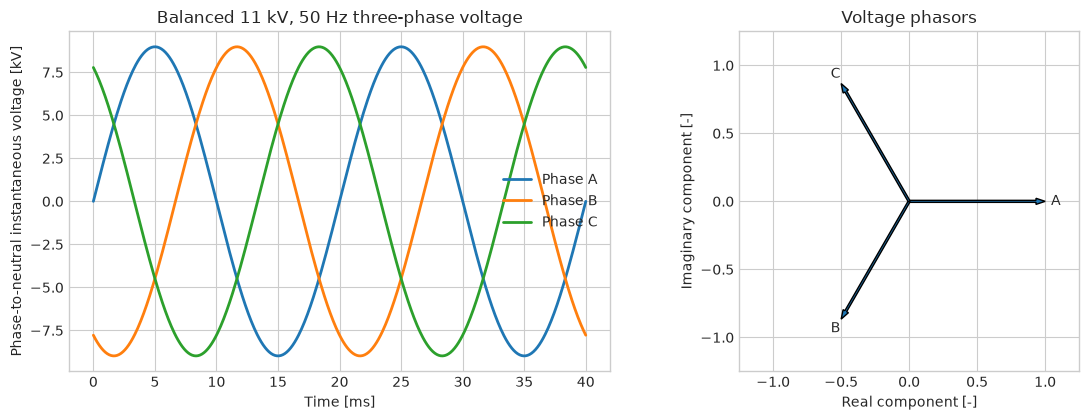

,Quantity,Value,Unit
0,Frequency,50.0000,Hz
1,Period,20.0000,ms
2,Line-to-line voltage,11.0000,kV RMS
3,Phase-to-neutral voltage,6.3509,kV RMS
4,Phase peak voltage,8.9815,kV


In [4]:
frequency_hz = 50.0
line_voltage_kv = 11.0
phase_voltage_kv = line_voltage_kv / math.sqrt(3.0)
time_s = np.linspace(0.0, 2.0 / frequency_hz, 500)
omega = 2.0 * np.pi * frequency_hz
phase_angles_deg = np.array([0.0, -120.0, 120.0])

phase_waveforms = []
for angle_deg in phase_angles_deg:
    angle_rad = np.deg2rad(angle_deg)
    waveform = math.sqrt(2.0) * phase_voltage_kv * np.sin(
        omega * time_s + angle_rad
    )
    phase_waveforms.append(waveform)

figure, axes = plt.subplots(1, 2, figsize=(12.0, 4.3))
labels = ["Phase A", "Phase B", "Phase C"]
for waveform, label in zip(phase_waveforms, labels):
    axes[0].plot(1000.0 * time_s, waveform, label=label, linewidth=2.0)
axes[0].set(
    title="Balanced 11 kV, 50 Hz three-phase voltage",
    xlabel="Time [ms]",
    ylabel="Phase-to-neutral instantaneous voltage [kV]",
)
axes[0].legend()

for angle_deg, label in zip(phase_angles_deg, labels):
    angle_rad = np.deg2rad(angle_deg)
    axes[1].arrow(
        0.0,
        0.0,
        np.cos(angle_rad),
        np.sin(angle_rad),
        width=0.015,
        length_includes_head=True,
        label=label,
    )
    axes[1].text(
        1.08 * np.cos(angle_rad),
        1.08 * np.sin(angle_rad),
        label[-1],
        ha="center",
        va="center",
    )
axes[1].set(
    title="Voltage phasors",
    xlabel="Real component [-]",
    ylabel="Imaginary component [-]",
    xlim=(-1.25, 1.25),
    ylim=(-1.25, 1.25),
    aspect="equal",
)
plt.tight_layout()
plt.show()

ac_summary = pd.DataFrame(
    [
        ["Frequency", frequency_hz, "Hz"],
        ["Period", 1000.0 / frequency_hz, "ms"],
        ["Line-to-line voltage", line_voltage_kv, "kV RMS"],
        ["Phase-to-neutral voltage", phase_voltage_kv, "kV RMS"],
        ["Phase peak voltage", math.sqrt(2.0) * phase_voltage_kv, "kV"],
    ],
    columns=["Quantity", "Value", "Unit"],
)
display(ac_summary)


## 2. Real, reactive, apparent, and complex power

Real power $P$ performs work or produces heat. Reactive power $Q$ establishes magnetic or
electric fields but increases current. Apparent power $S$ sizes generators, transformers,
switchgear, and cables. Power factor is $\cos\phi=P/S$ for sinusoidal balanced loads.

$$P=\sqrt{3}V_{LL}I\cos\phi$$

$$Q=\sqrt{3}V_{LL}I\sin\phi$$

$$S=\sqrt{P^2+Q^2}=\sqrt{3}V_{LL}I$$

The complex-power form is $\underline{S}=P+jQ$. Inductive motors normally consume positive
reactive power. Capacitors can supply reactive power locally, but capacitor banks must be
checked for switching transients and resonances, especially near converter harmonics.


In [5]:
example_real_power_mw = 5.0
example_power_factor = 0.85
example_angle_rad = math.acos(example_power_factor)
example_apparent_power_mva = example_real_power_mw / example_power_factor
example_reactive_power_mvar = example_real_power_mw * math.tan(
    example_angle_rad
)
example_current_a = 1000.0 * example_apparent_power_mva / (
    math.sqrt(3.0) * line_voltage_kv
)

target_power_factor = 0.95
capacitor_mvar = example_real_power_mw * (
    math.tan(math.acos(example_power_factor))
    - math.tan(math.acos(target_power_factor))
)
corrected_current_a = (
    1000.0
    * example_real_power_mw
    / target_power_factor
    / (math.sqrt(3.0) * line_voltage_kv)
)

power_triangle = pd.DataFrame(
    [
        ["Real power P", example_real_power_mw, "MW"],
        ["Reactive power Q", example_reactive_power_mvar, "MVAr"],
        ["Apparent power S", example_apparent_power_mva, "MVA"],
        ["Line current", example_current_a, "A"],
        ["Capacitor for PF 0.95", capacitor_mvar, "MVAr"],
        ["Corrected line current", corrected_current_a, "A"],
    ],
    columns=["Quantity", "Value", "Unit"],
)
display(power_triangle)


,Quantity,Value,Unit
0,Real power P,5.0000,MW
1,Reactive power Q,3.0987,MVAr
2,Apparent power S,5.8824,MVA
3,Line current,308.7435,A
4,Capacitor for PF 0.95,1.4553,MVAr
5,Corrected line current,276.2441,A


## 3. NeqSim process case: the two dominant rotating loads

The gas case uses SRK with the classic mixing rule, a normalized synthetic composition,
50 kg/s at 30 °C and 50 bara, and compression to 120 bara at 78% isentropic efficiency.

The water case uses SRK-CPA with mixing rule 10 for a liquid-water state, 18,000 m³/day at
25 °C and 40 bara, and injection pumping to 220 bara at 80% pump efficiency.

The NeqSim equipment powers are shaft duties. A pump's hydraulic efficiency belongs inside
the process model; the electric motor and VFD efficiencies belong downstream in the
electrical model.


In [6]:
GAS_COMPOSITION = {
    "nitrogen": 0.010,
    "CO2": 0.020,
    "methane": 0.870,
    "ethane": 0.060,
    "propane": 0.025,
    "n-butane": 0.010,
    "n-hexane": 0.005,
}
GAS_FLOW_KG_S = 50.0
WATER_FLOW_M3_DAY = 18_000.0
GAS_INLET_PRESSURE_BARA = 50.0
GAS_OUTLET_PRESSURE_BARA = 120.0
WATER_INLET_PRESSURE_BARA = 40.0
WATER_OUTLET_PRESSURE_BARA = 220.0
COMPRESSOR_EFFICIENCY = 0.78
PUMP_EFFICIENCY = 0.80

process_inputs = pd.DataFrame(
    [
        ["Gas flow", GAS_FLOW_KG_S, "kg/s", "Synthetic"],
        ["Gas suction pressure", GAS_INLET_PRESSURE_BARA, "bara", "Synthetic"],
        ["Gas discharge pressure", GAS_OUTLET_PRESSURE_BARA, "bara", "Synthetic"],
        ["Compressor isentropic efficiency", COMPRESSOR_EFFICIENCY, "-", "Synthetic"],
        ["Water injection flow", WATER_FLOW_M3_DAY, "m³/day", "Synthetic"],
        ["Water suction pressure", WATER_INLET_PRESSURE_BARA, "bara", "Synthetic"],
        ["Water discharge pressure", WATER_OUTLET_PRESSURE_BARA, "bara", "Synthetic"],
        ["Pump efficiency", PUMP_EFFICIENCY, "-", "Synthetic"],
    ],
    columns=["Input", "Value", "Unit", "Provenance"],
)
display(process_inputs)
print(f"Gas composition sum: {sum(GAS_COMPOSITION.values()):.6f}")


Gas composition sum: 1.000000


,Input,Value,Unit,Provenance
0,Gas flow,50.00,kg/s,Synthetic
1,Gas suction pressure,50.00,bara,Synthetic
2,Gas discharge pressure,120.00,bara,Synthetic
3,Compressor isentropic efficiency,0.78,-,Synthetic
4,Water injection flow,18000.00,m³/day,Synthetic
5,Water suction pressure,40.00,bara,Synthetic
6,Water discharge pressure,220.00,bara,Synthetic
7,Pump efficiency,0.80,-,Synthetic


In [7]:
def solve_process_loads(gas_flow_kg_s, water_flow_m3_day):
    gas = SystemSrkEos(30.0 + 273.15, GAS_INLET_PRESSURE_BARA)
    for component_name, mole_fraction in GAS_COMPOSITION.items():
        gas.addComponent(component_name, mole_fraction)
    gas.setMixingRule(2)
    gas.setTotalFlowRate(float(gas_flow_kg_s), "kg/sec")

    gas_feed = Stream("gas export compressor feed", gas)
    gas_compressor = Compressor("gas export compressor", gas_feed)
    gas_compressor.setOutletPressure(GAS_OUTLET_PRESSURE_BARA, "bara")
    gas_compressor.setIsentropicEfficiency(COMPRESSOR_EFFICIENCY)

    gas_process = ProcessSystem()
    gas_process.add(gas_feed)
    gas_process.add(gas_compressor)
    gas_process.run()

    water = SystemSrkCPA(25.0 + 273.15, WATER_INLET_PRESSURE_BARA)
    water.addComponent("water", 1.0)
    water.setMixingRule(10)
    water.setTotalFlowRate(float(water_flow_m3_day), "m3/day")

    water_feed = Stream("water injection pump feed", water)
    water_pump = Pump("water injection pump", water_feed)
    water_pump.setOutletPressure(WATER_OUTLET_PRESSURE_BARA, "bara")
    water_pump.setIsentropicEfficiency(PUMP_EFFICIENCY)

    water_process = ProcessSystem()
    water_process.add(water_feed)
    water_process.add(water_pump)
    water_process.run()

    return {
        "compressor_power_mw": float(gas_compressor.getPower("MW")),
        "compressor_outlet_c": float(
            gas_compressor.getOutletStream().getTemperature("C")
        ),
        "gas_in_kg_s": float(gas_feed.getFlowRate("kg/sec")),
        "gas_out_kg_s": float(
            gas_compressor.getOutletStream().getFlowRate("kg/sec")
        ),
        "pump_power_mw": float(water_pump.getPower("MW")),
        "pump_outlet_c": float(
            water_pump.getOutletStream().getTemperature("C")
        ),
        "water_in_kg_s": float(water_feed.getFlowRate("kg/sec")),
        "water_out_kg_s": float(
            water_pump.getOutletStream().getFlowRate("kg/sec")
        ),
    }


base_process = solve_process_loads(GAS_FLOW_KG_S, WATER_FLOW_M3_DAY)
process_results = pd.DataFrame(
    [
        ["Gas compressor shaft power", base_process["compressor_power_mw"], "MW"],
        ["Gas compressor discharge temperature", base_process["compressor_outlet_c"], "°C"],
        ["Water injection pump shaft power", base_process["pump_power_mw"], "MW"],
        ["Water pump discharge temperature", base_process["pump_outlet_c"], "°C"],
    ],
    columns=["Result", "Value", "Unit"],
)
display(process_results)


,Result,Value,Unit
0,Gas compressor shaft power,7.4687,MW
1,Gas compressor discharge temperature,108.8063,°C
2,Water injection pump shaft power,4.6274,MW
3,Water pump discharge temperature,27.2007,°C


### Independent pump-duty check

For an incompressible screening calculation, hydraulic power is $Q\Delta p$ and the required
shaft power is:

$$P_{\mathrm{shaft}}=\frac{Q\Delta p}{\eta_{\mathrm{pump}}}$$

This check is independent of the NeqSim pump implementation. It will not match exactly
because NeqSim uses a thermodynamic liquid state and enthalpy change rather than a constant
density incompressible approximation.


In [8]:
water_flow_m3_s = WATER_FLOW_M3_DAY / 86_400.0
water_delta_pressure_pa = (
    WATER_OUTLET_PRESSURE_BARA - WATER_INLET_PRESSURE_BARA
) * 1.0e5
analytical_pump_power_mw = (
    water_flow_m3_s
    * water_delta_pressure_pa
    / PUMP_EFFICIENCY
    / 1.0e6
)
pump_difference_percent = 100.0 * (
    base_process["pump_power_mw"] - analytical_pump_power_mw
) / analytical_pump_power_mw

pump_validation = pd.DataFrame(
    [
        ["NeqSim thermodynamic pump", base_process["pump_power_mw"], "MW"],
        ["Incompressible QΔp/η", analytical_pump_power_mw, "MW"],
        ["Relative difference", pump_difference_percent, "%"],
    ],
    columns=["Method", "Value", "Unit"],
)
display(pump_validation)


,Method,Value,Unit
0,NeqSim thermodynamic pump,4.6274,MW
1,Incompressible QΔp/η,4.6875,MW
2,Relative difference,-1.2831,%


## 4. Motors, drives, and the facility load list

Large compressors and pumps are often driven by high-voltage motors. A variable-frequency
drive (VFD) controls speed, limits starting current, and may improve process efficiency, but
introduces converter losses, harmonics, common-mode voltage, and motor-insulation and bearing
considerations.

The electrical input power for a rotating load is:

$$P_{\mathrm{grid}}=\frac{P_{\mathrm{shaft}}}{\eta_{\mathrm{motor}}\eta_{\mathrm{VFD}}}$$

Nameplate rating, continuous load, demand factor, spare philosophy, starting mode, and
essentiality are different fields and should never be collapsed into one number. Standby
equipment has installed capacity but normally zero coincident demand.


In [9]:
load_rows = [
    {
        "tag": "K-101",
        "service": "Gas export compressor",
        "quantity": 1,
        "shaft_mw_each": base_process["compressor_power_mw"],
        "motor_efficiency": 0.970,
        "drive_efficiency": 0.985,
        "power_factor": 0.960,
        "demand_factor": 1.00,
        "voltage_kv": 11.0,
        "starting": "VFD",
        "priority": 2,
    },
    {
        "tag": "P-201",
        "service": "Water injection pump",
        "quantity": 1,
        "shaft_mw_each": base_process["pump_power_mw"],
        "motor_efficiency": 0.965,
        "drive_efficiency": 0.985,
        "power_factor": 0.950,
        "demand_factor": 1.00,
        "voltage_kv": 11.0,
        "starting": "VFD",
        "priority": 3,
    },
    {
        "tag": "P-301A/B",
        "service": "Seawater lift pumps (1 operating)",
        "quantity": 1,
        "shaft_mw_each": 1.80,
        "motor_efficiency": 0.955,
        "drive_efficiency": 0.985,
        "power_factor": 0.950,
        "demand_factor": 1.00,
        "voltage_kv": 6.6,
        "starting": "VFD",
        "priority": 2,
    },
    {
        "tag": "P-302A/B/C",
        "service": "Cooling-water pumps (2 operating)",
        "quantity": 2,
        "shaft_mw_each": 0.65,
        "motor_efficiency": 0.945,
        "drive_efficiency": 0.985,
        "power_factor": 0.940,
        "demand_factor": 0.90,
        "voltage_kv": 6.6,
        "starting": "VFD",
        "priority": 2,
    },
    {
        "tag": "P-401A/B",
        "service": "Produced-water pump (1 operating)",
        "quantity": 1,
        "shaft_mw_each": 0.55,
        "motor_efficiency": 0.935,
        "drive_efficiency": 1.000,
        "power_factor": 0.880,
        "demand_factor": 0.85,
        "voltage_kv": 0.69,
        "starting": "Soft starter",
        "priority": 2,
    },
    {
        "tag": "K-501A/B",
        "service": "Instrument-air compressor (1 operating)",
        "quantity": 1,
        "shaft_mw_each": 0.45,
        "motor_efficiency": 0.930,
        "drive_efficiency": 1.000,
        "power_factor": 0.860,
        "demand_factor": 0.75,
        "voltage_kv": 0.69,
        "starting": "Soft starter",
        "priority": 1,
    },
    {
        "tag": "H-601",
        "service": "Electric heating and heat tracing",
        "quantity": 1,
        "shaft_mw_each": 1.20,
        "motor_efficiency": 1.000,
        "drive_efficiency": 1.000,
        "power_factor": 1.000,
        "demand_factor": 0.60,
        "voltage_kv": 0.40,
        "starting": "Static",
        "priority": 3,
    },
    {
        "tag": "L-701",
        "service": "HVAC, lighting, controls, and small power",
        "quantity": 1,
        "shaft_mw_each": 1.00,
        "motor_efficiency": 1.000,
        "drive_efficiency": 1.000,
        "power_factor": 0.950,
        "demand_factor": 1.00,
        "voltage_kv": 0.40,
        "starting": "Mixed",
        "priority": 1,
    },
]
loads = pd.DataFrame(load_rows)
loads["grid_mw_each"] = loads["shaft_mw_each"] / (
    loads["motor_efficiency"] * loads["drive_efficiency"]
)
loads["demand_mw"] = (
    loads["quantity"]
    * loads["grid_mw_each"]
    * loads["demand_factor"]
)
loads["demand_mvar"] = loads["demand_mw"] * np.tan(
    np.arccos(loads["power_factor"])
)
loads["demand_mva"] = np.hypot(
    loads["demand_mw"],
    loads["demand_mvar"],
)
loads["operating_current_a"] = 1000.0 * loads["demand_mva"] / (
    math.sqrt(3.0) * loads["voltage_kv"]
)

display(
    loads[
        [
            "tag",
            "service",
            "demand_mw",
            "demand_mvar",
            "demand_mva",
            "operating_current_a",
            "starting",
            "priority",
        ]
    ]
)


,tag,service,demand_mw,demand_mvar,demand_mva,operating_current_a,starting,priority
0,K-101,Gas export compressor,7.8170,2.2800,8.1427,427.3810,VFD,2
1,P-201,Water injection pump,4.8682,1.6001,5.1244,268.9629,VFD,3
2,P-301A/B,Seawater lift pumps (1 operating),1.9135,0.6289,2.0142,176.1995,VFD,2
3,P-302A/B/C,Cooling-water pumps (2 operating),1.2569,0.4562,1.3372,116.9729,VFD,2
4,P-401A/B,Produced-water pump (1 operating),0.5000,0.2699,0.5682,475.4202,Soft starter,2
5,K-501A/B,Instrument-air compressor (1 operating),0.3629,0.2153,0.4220,353.0878,Soft starter,1
6,H-601,Electric heating and heat tracing,0.7200,0.0000,0.7200,1039.2305,Static,3
7,L-701,"HVAC, lighting, controls, and small power",1.0000,0.3287,1.0526,1519.3428,Mixed,1


,Quantity,Value,Unit
0,Coincident real demand,18.4386,MW
1,Coincident reactive demand,5.7791,MVAr
2,Coincident apparent demand,19.3230,MVA
3,Aggregate power factor,0.9542,-


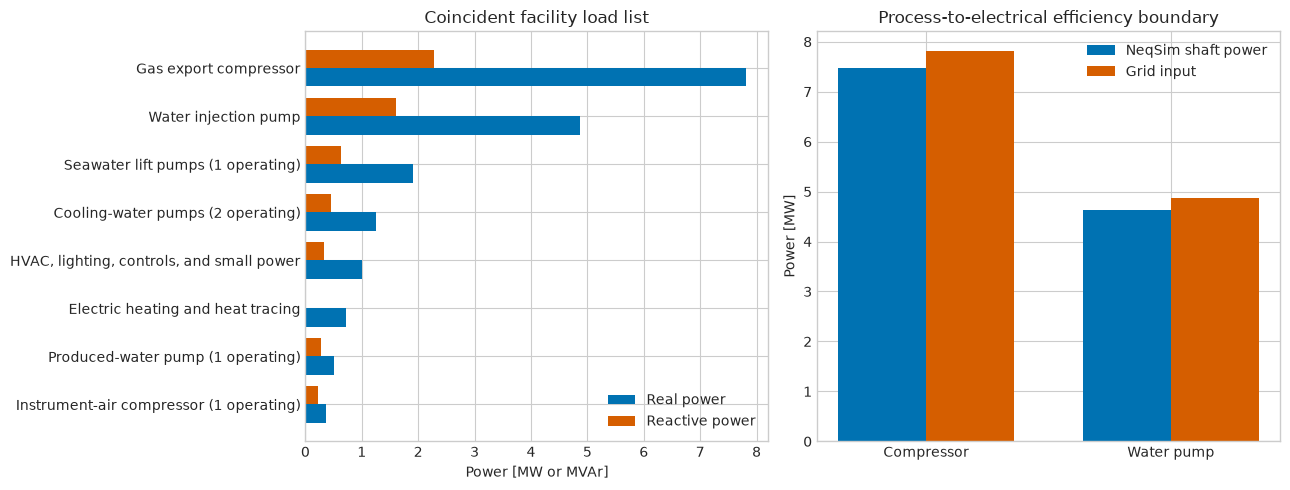

In [10]:
total_real_power_mw = loads["demand_mw"].sum()
total_reactive_power_mvar = loads["demand_mvar"].sum()
total_apparent_power_mva = math.hypot(
    total_real_power_mw,
    total_reactive_power_mvar,
)
facility_power_factor = total_real_power_mw / total_apparent_power_mva

facility_summary = pd.DataFrame(
    [
        ["Coincident real demand", total_real_power_mw, "MW"],
        ["Coincident reactive demand", total_reactive_power_mvar, "MVAr"],
        ["Coincident apparent demand", total_apparent_power_mva, "MVA"],
        ["Aggregate power factor", facility_power_factor, "-"],
    ],
    columns=["Quantity", "Value", "Unit"],
)
display(facility_summary)

ordered_loads = loads.sort_values("demand_mw", ascending=True)
figure, axes = plt.subplots(1, 2, figsize=(13.0, 5.0))
load_positions = np.arange(len(ordered_loads))
load_bar_height = 0.38
axes[0].barh(
    load_positions - load_bar_height / 2.0,
    ordered_loads["demand_mw"],
    load_bar_height,
    color=COLORS["process"],
    label="Real power",
)
axes[0].barh(
    load_positions + load_bar_height / 2.0,
    ordered_loads["demand_mvar"],
    load_bar_height,
    color=COLORS["electrical"],
    label="Reactive power",
)
axes[0].set(
    title="Coincident facility load list",
    xlabel="Power [MW or MVAr]",
    yticks=load_positions,
    yticklabels=ordered_loads["service"],
)
axes[0].legend()

process_names = ["Compressor", "Water pump"]
shaft_powers = [
    base_process["compressor_power_mw"],
    base_process["pump_power_mw"],
]
grid_powers = [
    loads.loc[loads["tag"] == "K-101", "grid_mw_each"].iloc[0],
    loads.loc[loads["tag"] == "P-201", "grid_mw_each"].iloc[0],
]
positions = np.arange(len(process_names))
width = 0.36
axes[1].bar(
    positions - width / 2.0,
    shaft_powers,
    width,
    label="NeqSim shaft power",
    color=COLORS["process"],
)
axes[1].bar(
    positions + width / 2.0,
    grid_powers,
    width,
    label="Grid input",
    color=COLORS["electrical"],
)
axes[1].set(
    title="Process-to-electrical efficiency boundary",
    ylabel="Power [MW]",
    xticks=positions,
    xticklabels=process_names,
)
axes[1].legend()
plt.tight_layout()
plt.show()


## 5. Transformers, voltage levels, and per-unit quantities

A practical facility uses several voltage levels: for example, grid or generator voltage,
11 kV for large motors, 6.6 kV for medium motors, 690/400 V for smaller loads, and AC/DC UPS
systems for controls and safety systems. Transformers provide voltage conversion and define
much of the short-circuit impedance.

The per-unit system normalizes voltage, power, current, and impedance to selected bases:

$$Z_{\mathrm{base}}=\frac{V_{LL,\mathrm{base}}^2}{S_{\mathrm{base}}}$$

$$Z_{\mathrm{pu}}=\frac{Z}{Z_{\mathrm{base}}}$$

Per-unit transformer impedance is approximately unchanged when referred across its turns
ratio, which makes multi-voltage calculations easier.


In [11]:
transformer_options = pd.DataFrame(
    [
        ["2 × 16 MVA", 2, 16.0],
        ["2 × 25 MVA", 2, 25.0],
        ["3 × 12.5 MVA", 3, 12.5],
    ],
    columns=["Concept", "Units", "Rating each [MVA]"],
)
transformer_options["Normal utilization [%]"] = (
    100.0
    * total_apparent_power_mva
    / (
        transformer_options["Units"]
        * transformer_options["Rating each [MVA]"]
    )
)
transformer_options["N-1 available [MVA]"] = (
    (transformer_options["Units"] - 1)
    * transformer_options["Rating each [MVA]"]
)
transformer_options["N-1 utilization [%]"] = (
    100.0
    * total_apparent_power_mva
    / transformer_options["N-1 available [MVA]"]
)
transformer_options["N-1 passes"] = (
    transformer_options["N-1 available [MVA]"]
    >= total_apparent_power_mva
)
display(transformer_options)

TRANSFORMER_RATING_MVA = 25.0
TRANSFORMER_IMPEDANCE_PU = 0.10
TRANSFORMER_X_R = 20.0
LV_BUS_KV = 11.0
HV_BUS_KV = 66.0
transformer_z_base_ohm = LV_BUS_KV**2 / TRANSFORMER_RATING_MVA
transformer_z_ohm = (
    TRANSFORMER_IMPEDANCE_PU * transformer_z_base_ohm
)
print(f"11 kV impedance base: {transformer_z_base_ohm:.4f} Ω")
print(f"Transformer impedance magnitude: {transformer_z_ohm:.4f} Ω")


11 kV impedance base: 4.8400 Ω
Transformer impedance magnitude: 0.4840 Ω


,Concept,Units,Rating each [MVA],Normal utilization [%],N-1 available [MVA],N-1 utilization [%],N-1 passes
0,2 × 16 MVA,2,16.0,60.3844,16.0,120.7689,False
1,2 × 25 MVA,2,25.0,38.6460,25.0,77.2921,True
2,3 × 12.5 MVA,3,12.5,51.5281,25.0,77.2921,True


### Transformer losses and operating temperature

No-load loss is nearly constant while copper loss scales approximately with current squared.
Real designs also check cooling class, ambient temperature, harmonics, tap range, inrush,
insulation coordination, fire separation, and cyclic loading. The loss model below is an
operating-energy screen, not a heat-run or life-consumption assessment.


In [12]:
no_load_loss_kw = 28.0
full_load_copper_loss_kw = 145.0
normal_share_mva = total_apparent_power_mva / 2.0
normal_loading_fraction = normal_share_mva / TRANSFORMER_RATING_MVA
loss_each_kw = no_load_loss_kw + full_load_copper_loss_kw * (
    normal_loading_fraction**2
)
pair_loss_kw = 2.0 * loss_each_kw
pair_efficiency = total_real_power_mw / (
    total_real_power_mw + pair_loss_kw / 1000.0
)

transformer_loss_summary = pd.DataFrame(
    [
        ["Load per transformer", normal_share_mva, "MVA"],
        ["Loading per transformer", 100.0 * normal_loading_fraction, "%"],
        ["Loss per transformer", loss_each_kw, "kW"],
        ["Pair loss", pair_loss_kw, "kW"],
        ["Pair efficiency", 100.0 * pair_efficiency, "%"],
    ],
    columns=["Quantity", "Value", "Unit"],
)
display(transformer_loss_summary)


,Quantity,Value,Unit
0,Load per transformer,9.6615,MVA
1,Loading per transformer,38.6460,%
2,Loss per transformer,49.6560,kW
3,Pair loss,99.3120,kW
4,Pair efficiency,99.4643,%


## 6. Cable current, losses, and voltage drop

A cable is not selected from current alone. A project checks voltage rating, normal and
emergency ampacity, route and grouping derating, ambient and soil/air conditions, conductor
temperature, voltage drop, short-circuit thermal withstand, fire performance, mechanical
protection, EMC, armour bonding, glands, hazardous-area installation, and vendor data.

For a balanced three-phase feeder, a common screening approximation is:

$$\Delta V_{LL}\approx\sqrt{3}IL(R\cos\phi+X\sin\phi)$$

Resistance increases with conductor temperature. The example deliberately exposes every
assumption instead of pretending to select a certified cable.


In [13]:
compressor_load = loads.loc[loads["tag"] == "K-101"].iloc[0]
feeder_length_km = 0.80
resistance_20c_ohm_km = 0.030
reactance_ohm_km = 0.080
copper_temperature_c = 90.0
copper_alpha_per_c = 0.00393
cable_ampacity_a = 600.0

resistance_hot_ohm_km = resistance_20c_ohm_km * (
    1.0 + copper_alpha_per_c * (copper_temperature_c - 20.0)
)
compressor_current_a = compressor_load["operating_current_a"]
compressor_phi_rad = math.acos(compressor_load["power_factor"])
voltage_drop_v = (
    math.sqrt(3.0)
    * compressor_current_a
    * feeder_length_km
    * (
        resistance_hot_ohm_km * compressor_load["power_factor"]
        + reactance_ohm_km * math.sin(compressor_phi_rad)
    )
)
voltage_drop_percent = 100.0 * voltage_drop_v / (LV_BUS_KV * 1000.0)
cable_loss_kw = (
    3.0
    * compressor_current_a**2
    * resistance_hot_ohm_km
    * feeder_length_km
    / 1000.0
)

cable_summary = pd.DataFrame(
    [
        ["Compressor feeder current", compressor_current_a, "A"],
        ["Illustrative cable ampacity", cable_ampacity_a, "A"],
        ["Hot conductor resistance", resistance_hot_ohm_km, "Ω/km"],
        ["Normal voltage drop", voltage_drop_percent, "%"],
        ["Normal cable loss", cable_loss_kw, "kW"],
    ],
    columns=["Quantity", "Value", "Unit"],
)
display(cable_summary)


,Quantity,Value,Unit
0,Compressor feeder current,427.3810,A
1,Illustrative cable ampacity,600.0000,A
2,Hot conductor resistance,0.0383,Ω/km
3,Normal voltage drop,0.3183,%
4,Normal cable loss,16.7690,kW


## 7. Short-circuit current: equipment duty, not only protection

Fault current determines switchgear making/breaking duty, busbar and cable thermal stress,
electrodynamic forces, voltage depression, and relay sensitivity. The exact study must model
source, generators, motors, converters, transformers, cables, earthing, topology, minimum and
maximum operating cases, and asymmetry.

This simplified IEC-style positive-sequence screen combines an upstream 750 MVA source and
one 25 MVA transformer with 10% impedance at the 11 kV bus. The initial symmetrical current is:

$$I_k''=\frac{cV_{LL}}{\sqrt{3}|Z_{\mathrm{th}}|}$$

The peak current uses $i_p=\kappa\sqrt{2}I_k''$ with an illustrative exponential $R/X$
correction. This is not a substitute for a complete IEC 60909 model.


In [14]:
source_fault_level_mva = 750.0
source_x_r = 10.0
voltage_factor = 1.10

def complex_impedance(magnitude_ohm, x_r_ratio):
    resistance = magnitude_ohm / math.sqrt(1.0 + x_r_ratio**2)
    reactance = resistance * x_r_ratio
    return complex(resistance, reactance)


source_z_hv_ohm = HV_BUS_KV**2 / source_fault_level_mva
source_z_lv_ohm = source_z_hv_ohm * (LV_BUS_KV / HV_BUS_KV) ** 2
source_impedance = complex_impedance(source_z_lv_ohm, source_x_r)
transformer_impedance = complex_impedance(
    transformer_z_ohm,
    TRANSFORMER_X_R,
)
thevenin_impedance = source_impedance + transformer_impedance
fault_current_ka = (
    voltage_factor
    * LV_BUS_KV
    / (math.sqrt(3.0) * abs(thevenin_impedance))
)
r_x_ratio = thevenin_impedance.real / thevenin_impedance.imag
kappa = 1.02 + 0.98 * math.exp(-3.0 * r_x_ratio)
peak_fault_current_ka = math.sqrt(2.0) * kappa * fault_current_ka
switchgear_short_time_rating_ka = 25.0

fault_summary = pd.DataFrame(
    [
        ["Source impedance referred to 11 kV", abs(source_impedance), "Ω"],
        ["Transformer impedance", abs(transformer_impedance), "Ω"],
        ["Thevenin R/X", r_x_ratio, "-"],
        ["Initial symmetrical fault current", fault_current_ka, "kA RMS"],
        ["Estimated peak fault current", peak_fault_current_ka, "kA peak"],
        ["Illustrative switchgear short-time rating", switchgear_short_time_rating_ka, "kA RMS"],
    ],
    columns=["Quantity", "Value", "Unit"],
)
display(fault_summary)


,Quantity,Value,Unit
0,Source impedance referred to 11 kV,0.1613,Ω
1,Transformer impedance,0.4840,Ω
2,Thevenin R/X,0.0625,-
3,Initial symmetrical fault current,10.8278,kA RMS
4,Estimated peak fault current,28.0613,kA peak
5,Illustrative switchgear short-time rating,25.0000,kA RMS


## 8. Starting a large compressor motor

A direct-on-line induction motor may draw roughly five to seven times rated current. That can
depress the bus voltage, reduce accelerating torque, disturb contactors and control systems,
and challenge generators. Soft starters reduce current but also reduce torque. VFDs can limit
grid current and provide controlled acceleration, but their control, harmonics, cooling,
bypass, and fault behaviour must be engineered.

The next calculation treats the motor as a locked-rotor impedance and solves a voltage divider
against the source-plus-transformer Thevenin impedance. The current therefore falls as terminal
voltage falls; it is more consistent than subtracting a fixed nominal starting-current drop.


,Starting method,Nominal current multiple,Actual start current [A],Motor terminal voltage [%],Voltage dip [%]
0,Direct on line,6.0,2040.3782,79.5691,20.4309
1,Soft starter,3.0,1136.4794,88.6391,11.3609
2,VFD ramp,1.1,449.0427,95.5168,4.4832


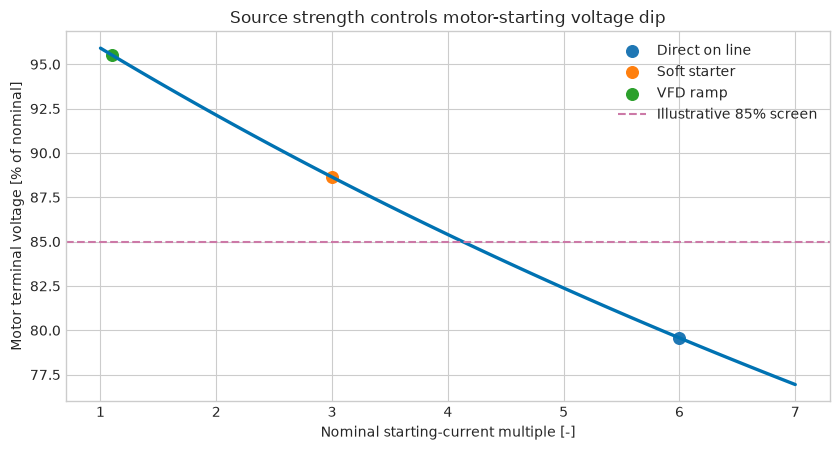

In [15]:
source_phase_voltage_v = LV_BUS_KV * 1000.0 / math.sqrt(3.0)
nominal_motor_current_a = compressor_current_a
locked_rotor_power_factor = 0.25

def starting_voltage(start_current_multiple):
    nominal_start_current_a = (
        start_current_multiple * nominal_motor_current_a
    )
    impedance_magnitude = source_phase_voltage_v / nominal_start_current_a
    impedance_angle = math.acos(locked_rotor_power_factor)
    motor_impedance = impedance_magnitude * complex(
        math.cos(impedance_angle),
        math.sin(impedance_angle),
    )
    terminal_voltage = source_phase_voltage_v * motor_impedance / (
        thevenin_impedance + motor_impedance
    )
    actual_current = terminal_voltage / motor_impedance
    return {
        "voltage_pu": abs(terminal_voltage) / source_phase_voltage_v,
        "current_a": abs(actual_current),
    }


starting_methods = {
    "Direct on line": 6.0,
    "Soft starter": 3.0,
    "VFD ramp": 1.10,
}
starting_rows = []
for method, current_multiple in starting_methods.items():
    result = starting_voltage(current_multiple)
    starting_rows.append(
        [
            method,
            current_multiple,
            result["current_a"],
            100.0 * result["voltage_pu"],
            100.0 * (1.0 - result["voltage_pu"]),
        ]
    )
starting_table = pd.DataFrame(
    starting_rows,
    columns=[
        "Starting method",
        "Nominal current multiple",
        "Actual start current [A]",
        "Motor terminal voltage [%]",
        "Voltage dip [%]",
    ],
)
display(starting_table)

current_multiples = np.linspace(1.0, 7.0, 121)
voltage_pu = np.array(
    [starting_voltage(value)["voltage_pu"] for value in current_multiples]
)
plt.figure(figsize=(8.5, 4.6))
plt.plot(
    current_multiples,
    100.0 * voltage_pu,
    linewidth=2.4,
    color=COLORS["process"],
)
for method, multiple in starting_methods.items():
    result = starting_voltage(multiple)
    plt.scatter(
        multiple,
        100.0 * result["voltage_pu"],
        s=70,
        label=method,
    )
plt.axhline(85.0, color=COLORS["warning"], linestyle="--", label="Illustrative 85% screen")
plt.xlabel("Nominal starting-current multiple [-]")
plt.ylabel("Motor terminal voltage [% of nominal]")
plt.title("Source strength controls motor-starting voltage dip")
plt.legend()
plt.tight_layout()
plt.show()


## 9. Protection and selectivity

Protection should isolate the smallest possible faulty section while preserving essential
production and safety functions. Typical functions include phase overcurrent, earth fault,
transformer differential, motor thermal and negative-sequence protection, under/overvoltage,
under/overfrequency, loss of excitation, reverse power, busbar protection, and arc detection.

A relay curve must sit above normal load and permitted starting, below equipment damage
limits, remain sensitive to the minimum fault, coordinate with downstream protection, and
trip the correct breaker. The illustrative inverse-time curve below uses:

$$t=\frac{\mathrm{TMS}\,k}{(I/I_p)^\alpha-1}$$

The constants demonstrate curve shape only. They are not relay settings.


Coordination margin at 5 kA: 0.386 s


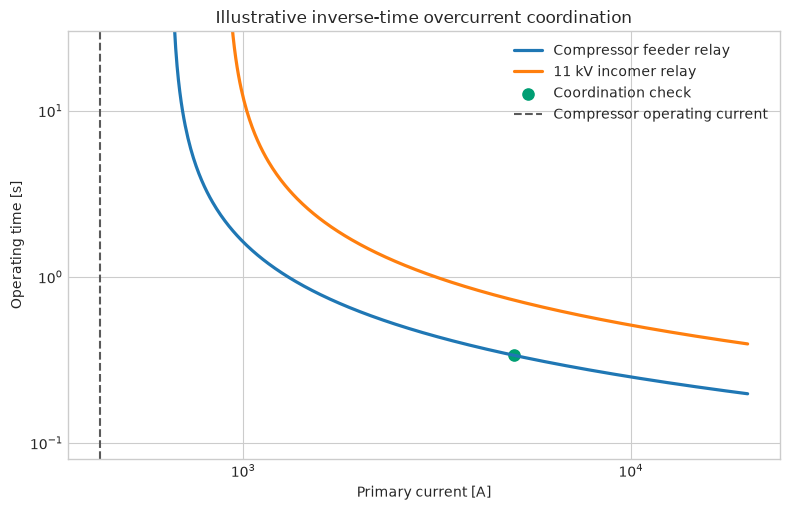

In [16]:
def inverse_time_seconds(current_a, pickup_a, time_multiplier):
    ratio = np.asarray(current_a) / pickup_a
    time_s = time_multiplier * 0.14 / (ratio**0.02 - 1.0)
    return np.where(ratio > 1.0, time_s, np.nan)


relay_current_a = np.geomspace(350.0, 20_000.0, 500)
downstream_pickup_a = 650.0
upstream_pickup_a = 900.0
downstream_tms = 0.10
upstream_tms = 0.18
downstream_time_s = inverse_time_seconds(
    relay_current_a,
    downstream_pickup_a,
    downstream_tms,
)
upstream_time_s = inverse_time_seconds(
    relay_current_a,
    upstream_pickup_a,
    upstream_tms,
)

coordination_current_a = 5_000.0
downstream_coordination_s = float(
    inverse_time_seconds(
        coordination_current_a,
        downstream_pickup_a,
        downstream_tms,
    )
)
upstream_coordination_s = float(
    inverse_time_seconds(
        coordination_current_a,
        upstream_pickup_a,
        upstream_tms,
    )
)
coordination_margin_s = (
    upstream_coordination_s - downstream_coordination_s
)

plt.figure(figsize=(8.0, 5.2))
plt.loglog(
    relay_current_a,
    downstream_time_s,
    label="Compressor feeder relay",
    linewidth=2.3,
)
plt.loglog(
    relay_current_a,
    upstream_time_s,
    label="11 kV incomer relay",
    linewidth=2.3,
)
plt.scatter(
    [coordination_current_a],
    [downstream_coordination_s],
    color=COLORS["safe"],
    s=65,
    label="Coordination check",
)
plt.axvline(
    compressor_current_a,
    color=COLORS["neutral"],
    linestyle="--",
    label="Compressor operating current",
)
plt.xlabel("Primary current [A]")
plt.ylabel("Operating time [s]")
plt.title("Illustrative inverse-time overcurrent coordination")
plt.ylim(0.08, 30.0)
plt.legend()
plt.tight_layout()
plt.show()

print(f"Coordination margin at 5 kA: {coordination_margin_s:.3f} s")


## 10. Power quality: harmonics, unbalance, and converters

VFDs are nonlinear loads. A six-pulse rectifier produces characteristic current harmonics
near orders $h=6n\pm1$; transformers, passive/active filters, multi-pulse arrangements, or
active front ends can reduce their effect. IEEE 519 applies harmonic objectives at the point
of common coupling, not as a universal limit at every internal load terminal.

Total harmonic distortion is:

$$\mathrm{THD}_I=\frac{\sqrt{\sum_{h=2}^{\infty}I_h^2}}{I_1}$$

Voltage unbalance is particularly important for induction motors because negative-sequence
current increases heating and reduces usable torque. Harmonic and unbalance studies require
vendor spectra and the actual network impedance over frequency.


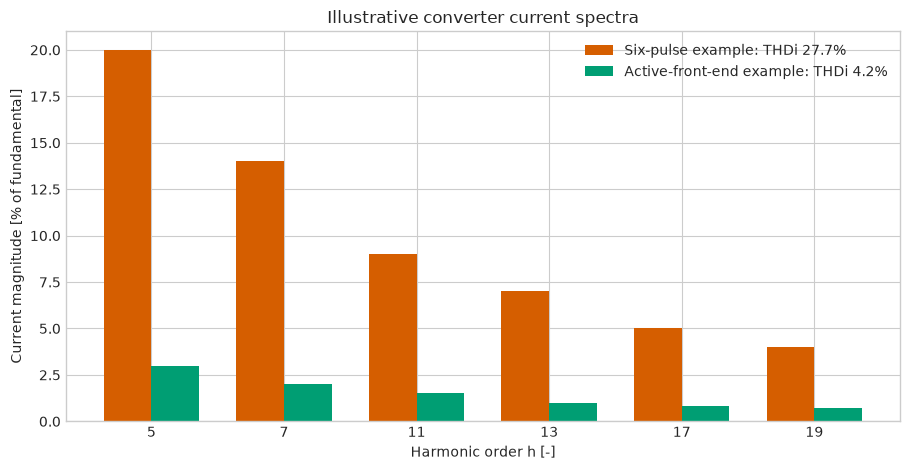

In [17]:
harmonic_orders = np.array([1, 5, 7, 11, 13, 17, 19])
six_pulse_current_percent = np.array([100.0, 20.0, 14.0, 9.0, 7.0, 5.0, 4.0])
active_front_end_percent = np.array([100.0, 3.0, 2.0, 1.5, 1.0, 0.8, 0.7])

def thd_percent(harmonic_percent):
    return float(np.sqrt(np.sum(harmonic_percent[1:] ** 2)))


six_pulse_thdi_percent = thd_percent(six_pulse_current_percent)
active_front_end_thdi_percent = thd_percent(active_front_end_percent)

plotted_orders = harmonic_orders[1:]
plotted_six_pulse = six_pulse_current_percent[1:]
plotted_active_front_end = active_front_end_percent[1:]
positions = np.arange(len(plotted_orders))
width = 0.36
plt.figure(figsize=(9.2, 4.8))
plt.bar(
    positions - width / 2.0,
    plotted_six_pulse,
    width,
    label=f"Six-pulse example: THDi {six_pulse_thdi_percent:.1f}%",
    color=COLORS["electrical"],
)
plt.bar(
    positions + width / 2.0,
    plotted_active_front_end,
    width,
    label=f"Active-front-end example: THDi {active_front_end_thdi_percent:.1f}%",
    color=COLORS["safe"],
)
plt.xticks(positions, plotted_orders)
plt.xlabel("Harmonic order h [-]")
plt.ylabel("Current magnitude [% of fundamental]")
plt.title("Illustrative converter current spectra")
plt.legend()
plt.tight_layout()
plt.show()


## 11. Earthing, hazardous areas, and electrical safety

These topics are system decisions, not afterthoughts.

| Topic | Engineering purpose | Oil and gas operating consequence |
|---|---|---|
| System earthing | Controls earth-fault current and touch voltage | Determines whether the first fault alarms or trips and how earth-fault protection is designed |
| Protective bonding | Maintains equipotential metallic structures | Reduces dangerous touch voltage and supports fault clearing |
| Lightning and surge protection | Routes impulse energy and limits overvoltage | Protects exposed structures, telecoms, control systems, and long cables |
| Hazardous-area classification | Identifies where explosive gas atmospheres may occur | Drives equipment protection level, temperature class, gas group, installation, inspection, and maintenance |
| Isolation and lockout/tagout | Establishes a verified de-energized work condition | Prevents energization, stored-energy release, and backfeed during maintenance |
| Arc-flash assessment | Quantifies incident-energy and boundary hazards | Informs equipment design, remote operation, work method, and PPE; it is not calculated in this notebook |

Offshore systems may use insulated, impedance-earthed, or solidly earthed arrangements at
different voltage levels. There is no universally correct choice: continuity, fault level,
selectivity, touch voltage, transient overvoltage, detection, and regulatory requirements
must be evaluated together.

Zone 0, 1, and 2 describe the likelihood/duration of explosive gas atmospheres. Protection
concepts such as intrinsic safety, flameproof enclosures, increased safety, and pressurization
solve different ignition risks. A process simulation can support release and ventilation
studies, but it does not assign electrical-area classification or certify Ex equipment.


## 12. Reliability, essential power, UPS, and load shedding

Production availability and safety availability are related but not identical. Two 25 MVA
transformers can each carry this teaching load, so loss of either transformer does not
immediately require load shedding. Redundancy only works if common-cause failures, bus
sectionalization, protection zones, cooling, cabling, controls, and maintenance access are
also independent enough.

Typical layers include:

- **normal AC:** process motors, utilities, heating, and accommodation;
- **essential AC:** selected utilities, control power, communications, and safe shutdown;
- **emergency generator:** fire and emergency services and recovery loads after loss of normal
  power, according to the facility philosophy;
- **UPS AC/DC:** uninterrupted control, SIS/ESD, telecoms, critical instrumentation, and breaker
  tripping/closing energy; and
- **black-start/load shedding:** restores sources and loads in a stable priority sequence.

Firewater pumps are safety-critical but normally require an emergency-rated prime mover or
supply arrangement, not merely a conventional UPS.


In [18]:
transformer_availability = 0.985
single_transformer_available = transformer_availability
at_least_one_transformer_available = 1.0 - (
    1.0 - transformer_availability
) ** 2

critical_loads = pd.DataFrame(
    [
        ["SIS/ESD logic and field I/O", 0.08, "UPS DC/AC", 1],
        ["Telecoms and control network", 0.12, "UPS AC/DC", 1],
        ["Emergency lighting", 0.10, "UPS/emergency AC", 1],
        ["Instrument air minimum train", 0.50, "Emergency AC", 1],
        ["Firewater service", 1.50, "Dedicated emergency supply", 1],
        ["HVAC minimum safe operation", 0.30, "Emergency AC", 1],
        ["Gas export compressor", loads.loc[0, "demand_mw"], "Normal AC", 2],
        ["Water injection pump", loads.loc[1, "demand_mw"], "Normal AC", 3],
    ],
    columns=["Service", "Power [MW]", "Supply class", "Priority"],
)
display(critical_loads)

reliability_summary = pd.DataFrame(
    [
        ["One transformer availability", single_transformer_available],
        ["At least one of two available", at_least_one_transformer_available],
        [
            "Unavailability reduction factor",
            (1.0 - single_transformer_available)
            / (1.0 - at_least_one_transformer_available),
        ],
    ],
    columns=["Metric", "Value"],
)
display(reliability_summary)


,Service,Power [MW],Supply class,Priority
0,SIS/ESD logic and field I/O,0.0800,UPS DC/AC,1
1,Telecoms and control network,0.1200,UPS AC/DC,1
2,Emergency lighting,0.1000,UPS/emergency AC,1
3,Instrument air minimum train,0.5000,Emergency AC,1
4,Firewater service,1.5000,Dedicated emergency supply,1
5,HVAC minimum safe operation,0.3000,Emergency AC,1
6,Gas export compressor,7.8170,Normal AC,2
7,Water injection pump,4.8682,Normal AC,3


,Metric,Value
0,One transformer availability,0.9850
1,At least one of two available,0.9998
2,Unavailability reduction factor,66.6667


## 13. Operations: process throughput changes electrical loading

Electrical demand is not a single design-point number. Production decline, compression ratio,
water cut, injection target, ambient conditions, recycle, fouling, equipment degradation, and
control strategy all move the operating point.

The following cases rebuild and solve the NeqSim compressor and pump at each throughput. The
result is passed through the same motor/VFD efficiency boundary. This is the reusable pattern
for joining production optimization to an electrical capacity constraint.


,Production factor [-],Compressor shaft [MW],Pump shaft [MW],Facility demand [MW],Facility demand [MVA],N-1 transformer utilization [%]
0,0.6,4.4812,2.7764,13.3645,14.0171,56.0682
1,0.7,5.2281,3.2391,14.6330,15.3435,61.3742
2,0.8,5.9750,3.7019,15.9015,16.6700,66.6801
3,0.9,6.7219,4.1646,17.1701,17.9965,71.9861
4,1.0,7.4687,4.6274,18.4386,19.3230,77.2921
5,1.1,8.2156,5.0901,19.7071,20.6495,82.5981
6,1.2,8.9625,5.5528,20.9756,21.9760,87.9041


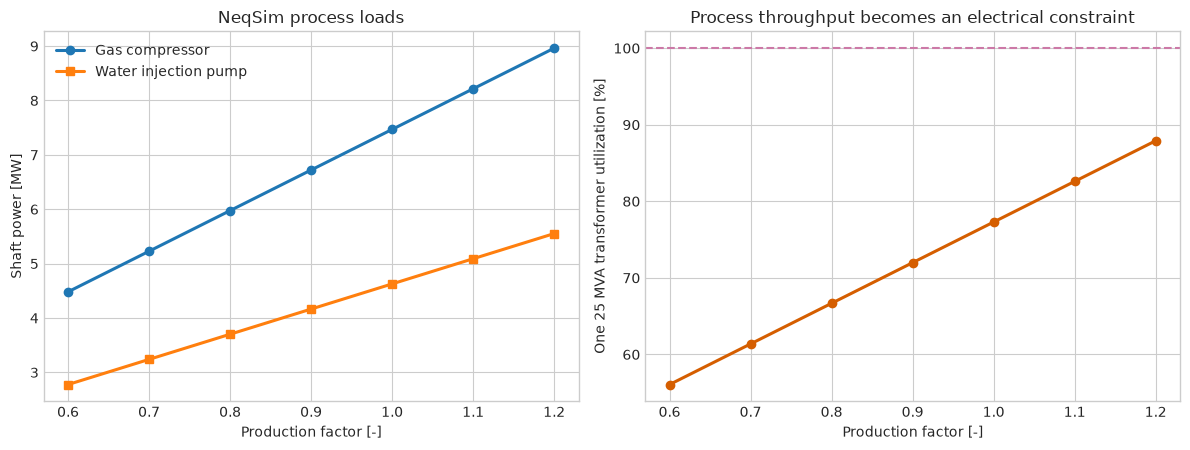

In [19]:
production_factors = np.linspace(0.60, 1.20, 7)
sensitivity_rows = []
other_facility_mw = total_real_power_mw - (
    loads.loc[0, "demand_mw"] + loads.loc[1, "demand_mw"]
)
other_facility_mvar = total_reactive_power_mvar - (
    loads.loc[0, "demand_mvar"] + loads.loc[1, "demand_mvar"]
)

for factor in production_factors:
    result = solve_process_loads(
        GAS_FLOW_KG_S * factor,
        WATER_FLOW_M3_DAY * factor,
    )
    compressor_grid_mw = result["compressor_power_mw"] / (
        loads.loc[0, "motor_efficiency"]
        * loads.loc[0, "drive_efficiency"]
    )
    pump_grid_mw = result["pump_power_mw"] / (
        loads.loc[1, "motor_efficiency"]
        * loads.loc[1, "drive_efficiency"]
    )
    compressor_mvar = compressor_grid_mw * math.tan(
        math.acos(loads.loc[0, "power_factor"])
    )
    pump_mvar = pump_grid_mw * math.tan(
        math.acos(loads.loc[1, "power_factor"])
    )
    case_mw = other_facility_mw + compressor_grid_mw + pump_grid_mw
    case_mvar = other_facility_mvar + compressor_mvar + pump_mvar
    case_mva = math.hypot(case_mw, case_mvar)
    sensitivity_rows.append(
        [
            factor,
            result["compressor_power_mw"],
            result["pump_power_mw"],
            case_mw,
            case_mva,
            100.0 * case_mva / TRANSFORMER_RATING_MVA,
        ]
    )

sensitivity = pd.DataFrame(
    sensitivity_rows,
    columns=[
        "Production factor [-]",
        "Compressor shaft [MW]",
        "Pump shaft [MW]",
        "Facility demand [MW]",
        "Facility demand [MVA]",
        "N-1 transformer utilization [%]",
    ],
)
display(sensitivity)

figure, axes = plt.subplots(1, 2, figsize=(12.0, 4.6))
axes[0].plot(
    sensitivity["Production factor [-]"],
    sensitivity["Compressor shaft [MW]"],
    marker="o",
    linewidth=2.2,
    label="Gas compressor",
)
axes[0].plot(
    sensitivity["Production factor [-]"],
    sensitivity["Pump shaft [MW]"],
    marker="s",
    linewidth=2.2,
    label="Water injection pump",
)
axes[0].set(
    title="NeqSim process loads",
    xlabel="Production factor [-]",
    ylabel="Shaft power [MW]",
)
axes[0].legend()

axes[1].plot(
    sensitivity["Production factor [-]"],
    sensitivity["N-1 transformer utilization [%]"],
    marker="o",
    linewidth=2.2,
    color=COLORS["electrical"],
)
axes[1].axhline(100.0, color=COLORS["warning"], linestyle="--")
axes[1].set(
    title="Process throughput becomes an electrical constraint",
    xlabel="Production factor [-]",
    ylabel="One 25 MVA transformer utilization [%]",
)
plt.tight_layout()
plt.show()


### A 24-hour operating profile and contingency screen

Real load flow uses the network topology and voltage-dependent models. This transparent
single-bus profile instead demonstrates how production, water injection, and auxiliary loads
combine over time. It checks normal two-transformer sharing and the N-1 case with one 25 MVA
transformer in service.


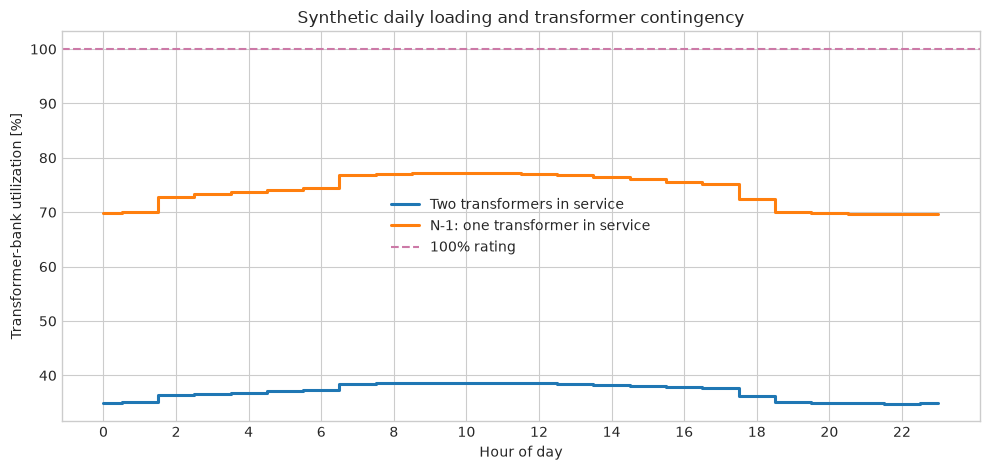

,Quantity,Value,Unit
0,Minimum facility demand,17.4047,MVA
1,Maximum facility demand,19.3184,MVA
2,Maximum N-1 transformer utilization,77.2737,%


In [20]:
hours = np.arange(24)
gas_factor = 0.92 + 0.05 * np.sin(2.0 * np.pi * (hours - 4.0) / 24.0)
injection_factor = np.where((hours >= 2) & (hours < 18), 1.0, 0.88)
auxiliary_factor = np.where((hours >= 7) & (hours < 19), 1.04, 0.96)

compressor_base_grid_mw = loads.loc[0, "grid_mw_each"]
pump_base_grid_mw = loads.loc[1, "grid_mw_each"]
hourly_real_mw = (
    compressor_base_grid_mw * gas_factor
    + pump_base_grid_mw * injection_factor
    + other_facility_mw * auxiliary_factor
)
hourly_reactive_mvar = (
    hourly_real_mw * total_reactive_power_mvar / total_real_power_mw
)
hourly_apparent_mva = np.hypot(hourly_real_mw, hourly_reactive_mvar)
normal_transformer_utilization = (
    100.0 * hourly_apparent_mva / (2.0 * TRANSFORMER_RATING_MVA)
)
contingency_transformer_utilization = (
    100.0 * hourly_apparent_mva / TRANSFORMER_RATING_MVA
)

plt.figure(figsize=(10.0, 4.8))
plt.step(
    hours,
    normal_transformer_utilization,
    where="mid",
    linewidth=2.2,
    label="Two transformers in service",
)
plt.step(
    hours,
    contingency_transformer_utilization,
    where="mid",
    linewidth=2.2,
    label="N-1: one transformer in service",
)
plt.axhline(100.0, color=COLORS["warning"], linestyle="--", label="100% rating")
plt.xlabel("Hour of day")
plt.ylabel("Transformer-bank utilization [%]")
plt.title("Synthetic daily loading and transformer contingency")
plt.xticks(np.arange(0, 24, 2))
plt.legend()
plt.tight_layout()
plt.show()

profile_summary = pd.DataFrame(
    [
        ["Minimum facility demand", hourly_apparent_mva.min(), "MVA"],
        ["Maximum facility demand", hourly_apparent_mva.max(), "MVA"],
        [
            "Maximum N-1 transformer utilization",
            contingency_transformer_utilization.max(),
            "%",
        ],
    ],
    columns=["Quantity", "Value", "Unit"],
)
display(profile_summary)


## 14. What Python tools add—and where specialist tools take over

| Need | This notebook | Typical specialist handoff |
|---|---|---|
| Thermodynamics and equipment duty | NeqSim via JPype | Calibrated process model and vendor curves |
| Load list, cases, and audits | pandas | Controlled project load database |
| Phasors, impedance, spectra, profiles | NumPy | Network-model data exchange |
| Root finding and numerical studies | SciPy | Verified load-flow/short-circuit solver |
| Technical figures | Matplotlib | Project reports and dashboards |
| Balanced load flow | Transparent approximations | pandapower, PyPSA, PowerFactory, ETAP, or SKM as appropriate |
| Protection and arc flash | Concept and curve shape only | Relay/vendor software and approved engineering method |
| Hazardous areas and Ex compliance | Concepts only | Multidiscipline area-classification dossier and certification |

Open-source Python tools are excellent for automation, QA, uncertainty, optimization, and
transparent coupling. They do not remove the need for governed data, validated component
models, independent verification, and accountable engineering approval.


## 15. Validation gates

The checks below cover composition, process conservation, an independent pump-power
comparison, electrical identities, equipment loading, contingency capacity, starting,
short-circuit duty, protection ordering, harmonics, and operating sensitivity. Passing these
checks demonstrates internal consistency of this teaching case; it does not certify a design.


In [21]:
validation_checks = {
    "gas composition is normalized": abs(sum(GAS_COMPOSITION.values()) - 1.0) < 1.0e-12,
    "compressor mass is conserved": abs(
        base_process["gas_in_kg_s"] - base_process["gas_out_kg_s"]
    )
    < 1.0e-9,
    "pump mass is conserved": abs(
        base_process["water_in_kg_s"]
        - base_process["water_out_kg_s"]
    )
    < 1.0e-9,
    "compressor duty is positive": base_process["compressor_power_mw"] > 0.0,
    "pump duty is positive": base_process["pump_power_mw"] > 0.0,
    "compressor discharge is hotter": base_process["compressor_outlet_c"] > 30.0,
    "pump analytical check is within 3 percent": abs(pump_difference_percent) < 3.0,
    "all load power factors are physical": bool(
        loads["power_factor"].between(0.0, 1.0, inclusive="right").all()
    ),
    "grid input exceeds shaft load": bool(
        (
            loads["grid_mw_each"]
            >= loads["shaft_mw_each"] - 1.0e-12
        ).all()
    ),
    "facility power triangle closes": abs(
        total_apparent_power_mva
        - math.hypot(total_real_power_mw, total_reactive_power_mvar)
    )
    < 1.0e-12,
    "facility power factor exceeds 0.90": facility_power_factor > 0.90,
    "two 25 MVA transformers pass N-1": (
        TRANSFORMER_RATING_MVA >= total_apparent_power_mva
    ),
    "normal compressor cable current is below ampacity": (
        compressor_current_a < cable_ampacity_a
    ),
    "normal feeder voltage drop is below 3 percent": voltage_drop_percent < 3.0,
    "switchgear RMS rating exceeds calculated fault": (
        switchgear_short_time_rating_ka > fault_current_ka
    ),
    "fault current exceeds load current": (
        1000.0 * fault_current_ka > 10.0 * compressor_current_a
    ),
    "VFD start voltage exceeds DOL start voltage": (
        starting_table.loc[2, "Motor terminal voltage [%]"]
        > starting_table.loc[0, "Motor terminal voltage [%]"]
    ),
    "VFD terminal voltage exceeds 95 percent": (
        starting_table.loc[2, "Motor terminal voltage [%]"] > 95.0
    ),
    "illustrative coordination margin is positive": coordination_margin_s > 0.0,
    "active front end has lower THDi": (
        active_front_end_thdi_percent < six_pulse_thdi_percent
    ),
    "compressor sensitivity is monotonic": bool(
        sensitivity["Compressor shaft [MW]"].is_monotonic_increasing
    ),
    "pump sensitivity is monotonic": bool(
        sensitivity["Pump shaft [MW]"].is_monotonic_increasing
    ),
    "maximum throughput remains within N-1 rating": (
        sensitivity["Facility demand [MVA]"].max()
        < TRANSFORMER_RATING_MVA
    ),
    "daily N-1 utilization remains below 100 percent": (
        contingency_transformer_utilization.max() < 100.0
    ),
    "source-built class is proven": neqsim_jar.name in class_location,
}
validation = pd.DataFrame(
    [
        [check_name, bool(passed)]
        for check_name, passed in validation_checks.items()
    ],
    columns=["Validation check", "Passed"],
)
display(validation)
passed_count = int(validation["Passed"].sum())
print(f"Passed {passed_count}/{len(validation)} validation checks")
failed_checks = validation.loc[
    ~validation["Passed"],
    "Validation check",
].tolist()
assert validation["Passed"].all(), failed_checks


Passed 25/25 validation checks


,Validation check,Passed
0,gas composition is normalized,True
1,compressor mass is conserved,True
2,pump mass is conserved,True
3,compressor duty is positive,True
4,pump duty is positive,True
5,compressor discharge is hotter,True
6,pump analytical check is within 3 percent,True
7,all load power factors are physical,True
8,grid input exceeds shaft load,True
9,facility power triangle closes,True


## 16. Engineering interpretation

For this synthetic base case:

- NeqSim shows that gas compression is the largest individual shaft load and water injection
  is the second largest. These two process decisions dominate the electrical concept.
- Motor and VFD losses make grid demand larger than shaft demand. Keeping the process/electrical
  boundary explicit prevents double counting.
- The coincident load fits one 25 MVA transformer, so a 2 × 25 MVA concept passes the simple
  N-1 capacity screen. Smaller alternatives do not automatically pass.
- The illustrative compressor feeder passes normal ampacity and voltage-drop screens, while
  motor starting depends strongly on the source impedance and starting technology.
- The calculated fault current is below the illustrative switchgear RMS rating, but a complete
  minimum/maximum fault and DC-offset duty study is still required.
- Production and injection changes move transformer utilization. Electrical capacity can
  therefore become an active constraint in process optimization rather than a fixed utility
  number.

A useful operational implementation would expose NeqSim process powers, bus measurements,
motor/VFD status, transformer temperature, breaker state, and constraints through a governed
data interface. Optimization should respect compressor maps, pump curves, process limits,
motor current, VFD power, transformer MVA, voltage, reserve, and contingency limits together.


## 17. Limitations and required next studies

- The network is balanced and positive-sequence. It omits detailed generators, motor fault
  contribution, converters, cable capacitance, zero-sequence networks, earthing impedances,
  unbalanced faults, and load-flow controls.
- Cable R/X and ampacity are illustrative. No cable size or installation method is selected.
- Transformer loss and availability data are synthetic; no overload or insulation-aging claim
  is made.
- Starting uses a locked-rotor impedance screen, not a dynamic motor/load torque simulation.
- Relay curves show a principle only; no current-transformer ratio, breaker time, damage curve,
  minimum fault, or approved setting is provided.
- Harmonic spectra are synthetic and cannot replace vendor spectra and frequency-dependent
  network impedance.
- Arc-flash, shock protection, hazardous-area classification, Ex selection, fire safety,
  cybersecurity, and functional safety require dedicated governed studies.
- The compressor and pump use fixed efficiencies and pressures; a project model should use
  maps, control logic, recycles, system curves, and calibrated operating data.

No NeqSim defect or distinct reusable API gap was found while building this notebook. The
process-to-electrical handoff works through existing public `getPower("MW")` methods.


## 18. Standards and authoritative starting points

Standards must be applied in their contractual and regulatory context. The links below are
official scope pages, not substitutes for licensed standards or project specifications.
They were checked on 22 August 2026.

- [IEC 61892-1:2019](https://webstore.iec.ch/en/publication/64956) and
  [IEC 61892-2:2019](https://webstore.iec.ch/en/publication/33805): electrical installations
  and system design for mobile and fixed offshore units.
- [IEC 61892-4:2019](https://webstore.iec.ch/en/publication/33651) and
  [IEC 61892-6:2019](https://webstore.iec.ch/en/publication/29080): offshore cable selection
  and installation.
- [IEC 60909-0:2026](https://webstore.iec.ch/en/publication/68454): short-circuit-current
  calculation in three-phase AC systems.
- [IEC 60034-1:2026](https://webstore.iec.ch/en/publication/89961) and
  [IEC 60034-2-3:2024](https://webstore.iec.ch/en/publication/67758): rotating-machine rating
  and converter-fed motor loss/efficiency testing.
- [IEC 60079-0:2026](https://webstore.iec.ch/en/publication/71519) and
  [IEC 60079-14:2024](https://webstore.iec.ch/en/publication/66049): Ex equipment and electrical
  installation in explosive atmospheres.
- [IEC 60364-1:2025](https://webstore.iec.ch/en/publication/63699): fundamental safety
  principles for low-voltage installations.
- [IEC 61850 series](https://webstore.iec.ch/en/publication/6028): communication networks and
  systems for power-utility automation.
- [IEEE 519-2022](https://standards.ieee.org/ieee/519/10677/): harmonic-control objectives at
  the point of common coupling.
- [Standards Norway: NORSOK electrical standards](https://standard.no/en/sectors/petroleum/norsok-standards/e-electrical):
  NCS electrical safety and design context. NORSOK E-001 was under systematic review when
  this notebook was prepared.
- [NeqSim source](https://github.com/equinor/neqsim) and
  [NeqSim documentation](https://equinor.github.io/neqsim/): thermodynamics and process
  equipment used to establish the shaft-duty boundary.


## 19. Suggested exercises

1. Change gas flow, pressure ratio, and compressor efficiency. Identify the first process or
   electrical constraint reached.
2. Replace the 2 × 25 MVA concept with 3 × 12.5 MVA and define a credible bus-section and
   maintenance philosophy.
3. Add a shore-power cable or gas-turbine generator model and repeat the starting and fault
   screens for each source configuration.
4. Add minimum and maximum fault cases, including motor contribution and an earthing model.
5. Replace the illustrative cable data with a public manufacturer datasheet and document
   installation derating, voltage drop, and short-circuit thermal checks.
6. Export the load list as CSV and build the same radial system in pandapower. Compare voltage
   and fault results and explain every difference.
7. Couple compressor speed or water-injection rate to an optimizer with transformer MVA,
   motor current, and voltage constraints.
8. Build an operational dashboard that distinguishes measured power, NeqSim-predicted shaft
   power, motor/VFD loss, electrical loss, and remaining contingency margin.
